In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from FEATURES.features import *
from PROPS_EV.calculateEVS import *
from BACKTEST.backtest import *
from MODELS.Models import *

In [2]:
modelPTS = joblib.load('../MODELS/Models/xgbPTSModel.pkl')
featuresPTS = joblib.load('../MODELS/Models/topPTSfeatures.pkl')
modelREB = joblib.load('../MODELS/Models/xgbREBModel.pkl')
featuresREB = joblib.load('../MODELS/Models/topREBfeatures.pkl')

In [3]:
pd.set_option('display.max_columns', None)

s25_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_25.csv')
s24_pts = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/PTS_TRAIN_24.csv')
s25_reb = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_25.csv')
s24_reb = pd.read_csv('../DATA/CSV_FILES/TRAIN_DATA/REB_TRAIN_24.csv')

dfPTS = pd.concat([s25_pts, s24_pts]).sort_values(by='GAME_DATE')
dfREB = pd.concat([s25_reb, s24_reb]).sort_values(by='GAME_DATE')

In [4]:
backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')
backtestData = backtestData[(backtestData['BOOKMAKER'] == 'prizepicks')]
backtestData

C:\Users\alexg\AppData\Local\Temp\ipykernel_20944\4101129247.py:1: DtypeWarning: Columns (11,12,14) have mixed types. Specify dtype option on import or set low_memory=False.
  backtestData = pd.read_csv('../DATA/CSV_FILES/BACKTEST_DATA/dfs_data.csv')


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,NAME,CATEGORY,BOOKMAKER,SIDE,LINE,ODDS,HOME_TEAM,AWAY_TEAM,game_id,commence_time,GAME_DATE,period_id,fair_line,fair_odds,OVER/ODDS
0,0,0,0,Miles McBride,player_points,prizepicks,under,8.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
1,1,1,1,OG Anunoby,player_assists,prizepicks,over,1.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
2,2,2,2,OG Anunoby,player_assists,prizepicks,under,1.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
3,3,3,3,Jayson Tatum,player_points,prizepicks,over,26.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,over
4,4,4,4,Jayson Tatum,player_points,prizepicks,under,26.5,-137,Boston Celtics,New York Knicks,92cf7db605a734b10e69eabf56e1eac9,2024-10-22T23:40:00Z,2024-10-22,NaN,NaN,NaN,under
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198089,198089,198089,119128,Malaki Branham,player_points,prizepicks,under,11.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,12.5,100.0,under
198093,198093,198093,119132,Garrett Temple,player_assists,prizepicks,under,3.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,4.0,100.0,under
198095,198095,198095,119134,Garrett Temple,player_points,prizepicks,under,9.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,9.5,-115.0,under
198097,198097,198097,119136,Garrett Temple,player_assists,prizepicks,over,3.5,-137,San Antonio Spurs,Toronto Raptors,NaN,NaN,2025-04-13,game,4.0,100.0,over


In [5]:
results = backtestPrizePicksPairs(dfREB, backtestData, '2025-03-15', modelREB, featuresREB, edge_threshold=2.0, top_n=10, simulations=10000, stat_col='REB')
results

Processing pairs...


,player1,player2,model_side1,model_side2,line1,line2,pred1,pred2,actual1,actual2,edge1,edge2,leg1_won,leg2_won,pair_recommendation,pair_won,ev_percent,probability,date
0,Isaiah Hartenstein,Walker Kessler,UNDER,OVER,11.5,10.5,7.85,14.76,6,14,-3.65,4.26,1,1,1,1,1.450,0.8168,2025-03-15
1,Day'Ron Sharpe,Isaiah Hartenstein,UNDER,UNDER,10.5,11.5,6.30,7.85,6,6,-4.20,-3.65,1,1,1,1,1.432,0.8106,2025-03-15
2,Isaiah Hartenstein,Jeremy Sochan,UNDER,UNDER,11.5,6.5,7.85,4.37,6,4,-3.65,-2.13,1,1,1,1,1.428,0.8093,2025-03-15
3,Isaiah Hartenstein,Naji Marshall,UNDER,UNDER,11.5,7.5,7.85,4.92,6,5,-3.65,-2.58,1,1,1,1,1.368,0.7893,2025-03-15
4,Cade Cunningham,Isaiah Hartenstein,OVER,UNDER,5.0,11.5,6.74,7.85,3,6,1.74,-3.65,0,1,0,0,1.305,0.7684,2025-03-15
5,Domantas Sabonis,Isaiah Hartenstein,UNDER,UNDER,11.5,11.5,8.96,7.85,11,6,-2.54,-3.65,1,1,1,1,1.267,0.7555,2025-03-15
6,Day'Ron Sharpe,Walker Kessler,UNDER,OVER,10.5,10.5,6.30,14.76,6,14,-4.20,4.26,1,1,1,1,1.180,0.7268,2025-03-15
7,Jeremy Sochan,Walker Kessler,UNDER,OVER,6.5,10.5,4.37,14.76,4,14,-2.13,4.26,1,1,1,1,1.177,0.7257,2025-03-15
8,Day'Ron Sharpe,Jeremy Sochan,UNDER,UNDER,10.5,6.5,6.30,4.37,6,4,-4.20,-2.13,1,1,1,1,1.161,0.7202,2025-03-15
9,Ausar Thompson,Isaiah Hartenstein,OVER,UNDER,5.0,11.5,6.92,7.85,4,6,1.92,-3.65,0,1,0,0,1.142,0.7141,2025-03-15


In [6]:
if not results.empty:
    # Overall metrics
    total_bets = len(results)
    total_wins = results['pair_won'].sum()
    win_rate = results['pair_won'].mean()
    
    # Metrics for recommended bets only
    recommended = results[results['pair_recommendation'] == 1]
    if not recommended.empty:
        rec_total = len(recommended)
        rec_wins = recommended['pair_won'].sum()
        rec_win_rate = recommended['pair_won'].mean()
        
        print(f"\n--- All Bets ---")
        print(f"Total: {total_bets}, Wins: {total_wins}, Win Rate: {win_rate:.2%}")
        print(f"\n--- Recommended Bets (Edge > 4.5) ---")
        print(f"Total: {rec_total}, Wins: {rec_wins}, Win Rate: {rec_win_rate:.2%}")


--- All Bets ---
Total: 10, Wins: 8, Win Rate: 80.00%

--- Recommended Bets (Edge > 4.5) ---
Total: 8, Wins: 8, Win Rate: 100.00%


In [8]:
uniqueDates = sorted(s25_pts['GAME_DATE'].unique())
all_results = []

for i, date in enumerate(uniqueDates, 1):
    print(f"Processing {date}... {i}/{len(uniqueDates)}")
    
    try:
        date_results = backtestPrizePicksPairs(dfREB, backtestData, date, modelREB, featuresREB, edge_threshold=2.0, top_n=10, simulations=10000, stat_col='REB')
        
        if not date_results.empty:
            all_results.append(date_results)
            print(f"  ✓ Processed {len(date_results)} bets")
        else:
            print(f"  No results for {date}")
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        continue

# Combine all results
if all_results:
    final_results = pd.concat(all_results, ignore_index=True)
    print(f"\n✓ Complete! Total bets analyzed: {len(final_results)}")



Processing 2024-10-23... 1/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-24... 2/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-25... 3/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-26... 4/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-27... 5/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-28... 6/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-29... 7/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-30... 8/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-10-31... 9/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-01... 10/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-02... 11/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-03... 12/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-04... 13/162
Processing pairs...
  ✓ Processed 10 bets
Processing 2024-11-06... 14/162
Processing pair

           COMPREHENSIVE BETTING ANALYSIS

 ALL BETS ANALYSIS:
   Total Bets: 1,406
   Wins: 451
   Hit Rate: 32.08%
   Total Profit: $-265.00
   Total Staked: $7,030.00
   ROI: -3.77%
   Volatility: $38.01
   Max Drawdown: $-635.00
   Sharpe Ratio: -0.587

 RECOMMENDED BETS ANALYSIS (Edge > 2.0):
   Total Bets: 461
   Wins: 196
   Hit Rate: 42.52%
   Total Profit: $635.00
   Total Staked: $2,305.00
   ROI: 27.55%
   Volatility: $24.90
   Max Drawdown: $-85.00
   Sharpe Ratio: 2.489


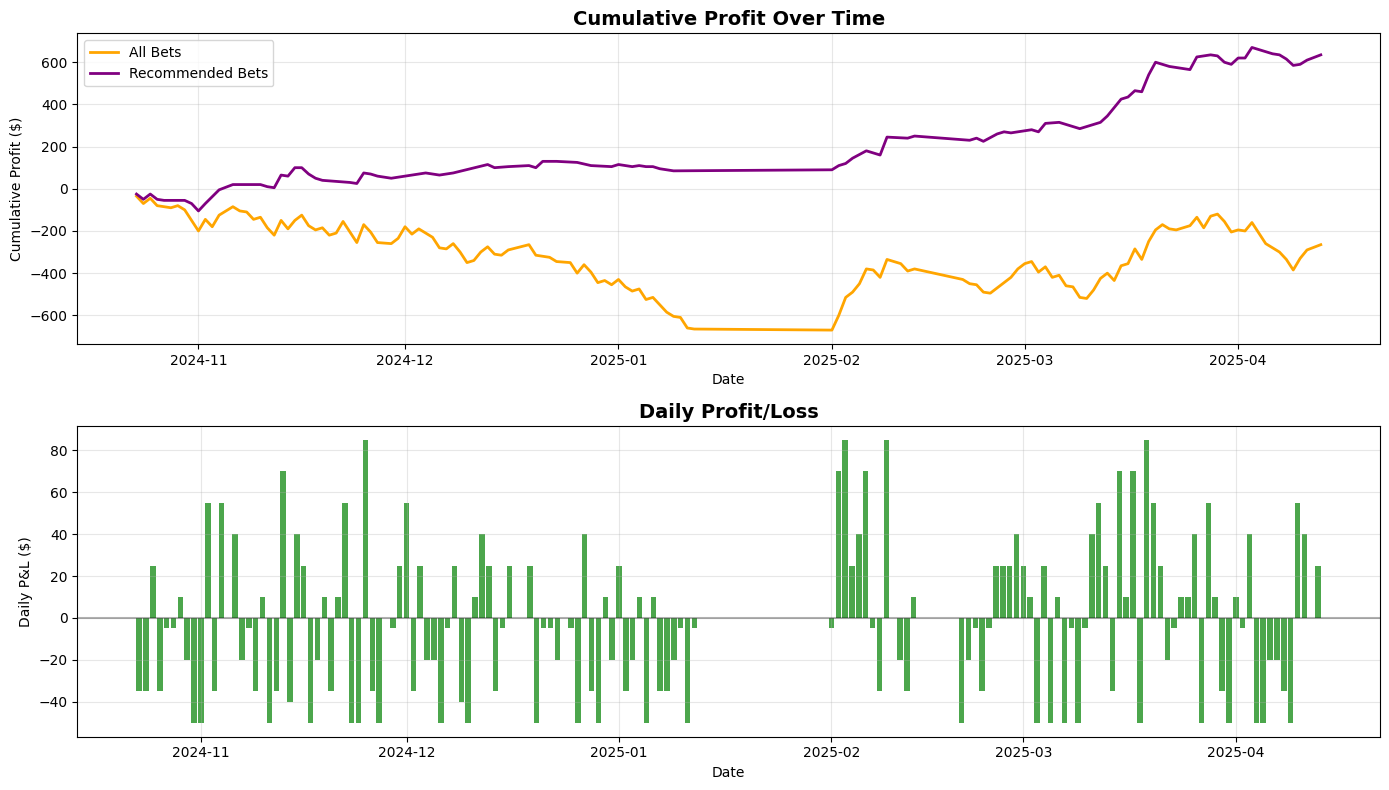

In [9]:
edge = 2.0
# Calculate metrics for all bets
all_metrics = calculatePairMetrics(final_results, stake=5)

# Calculate metrics for recommended bets only
recommended = final_results[final_results['pair_recommendation'] == 1]
rec_metrics = calculatePairMetrics(recommended, stake=5)

# Display comprehensive results
print("=" * 60)
print("           COMPREHENSIVE BETTING ANALYSIS")
print("=" * 60)

if all_metrics:
    print(f"\n ALL BETS ANALYSIS:")
    print(f"   Total Bets: {all_metrics['total_bets']:,}")
    print(f"   Wins: {all_metrics['total_wins']:,}")
    print(f"   Hit Rate: {all_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${all_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${all_metrics['total_staked']:,.2f}")
    print(f"   ROI: {all_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${all_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${all_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {all_metrics['sharpe_ratio']:.3f}")

if rec_metrics:
    print(f"\n RECOMMENDED BETS ANALYSIS (Edge > {edge}):")
    print(f"   Total Bets: {rec_metrics['total_bets']:,}")
    print(f"   Wins: {rec_metrics['total_wins']:,}")
    print(f"   Hit Rate: {rec_metrics['win_rate']:.2%}")
    print(f"   Total Profit: ${rec_metrics['total_profit']:,.2f}")
    print(f"   Total Staked: ${rec_metrics['total_staked']:,.2f}")
    print(f"   ROI: {rec_metrics['roi_percent']:.2f}%")
    print(f"   Volatility: ${rec_metrics['volatility']:.2f}")
    print(f"   Max Drawdown: ${rec_metrics['max_drawdown']:.2f}")
    print(f"   Sharpe Ratio: {rec_metrics['sharpe_ratio']:.3f}")

# Plots cumulative profit over time
if all_metrics and not all_metrics['daily_pnl'].empty:
    plt.figure(figsize=(14, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['cumulative_profit'], 
             linewidth=2, label='All Bets', color='orange')
    if rec_metrics and not rec_metrics['daily_pnl'].empty:
        plt.plot(rec_metrics['daily_pnl']['date'], rec_metrics['daily_pnl']['cumulative_profit'], 
                 linewidth=2, label='Recommended Bets', color='purple')
    plt.title('Cumulative Profit Over Time', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Profit ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 1, 2)
    plt.bar(all_metrics['daily_pnl']['date'], all_metrics['daily_pnl']['profit'], 
            alpha=0.7, label='Daily P&L', color='green')
    plt.title('Daily Profit/Loss', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Daily P&L ($)')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()